# Place Name Normalization

The resulting dataset (`data/clean/places.csv`) serves as the authoritative lookup table for all place references across the project, enabling consistent spatial analysis and record linkage.

Historical documents present significant challenges in place name identification due to spelling variations, ambiguous toponyms, and evolving geographic nomenclature. This notebook builds an authoritative gazetteer of unique places from two sources:

1. **Collaborator GIS data**: A curated GeoJSON (`data/testing/toponimos.geojson`) compiled by Grecia Roque from primary sources, providing canonical names, verified coordinates, and known spelling variants.
2. **Record matching**: Raw place mentions extracted from the sacramental records are linked to the GeoJSON entries via exact and fuzzy string matching.

## Data Preparation

We begin by loading the cleaned sacramental records, which have already undergone date normalization and attribute harmonization. Place names at this stage retain their original spelling variations as recorded in the historical documents.

In [1]:
import pandas as pd

In [ ]:
GEOJSON_PATH = '../data/manual/toponimos.geojson'

In [3]:
BAUTISMOS_HARMONIZED = pd.read_csv("../data/clean/bautismos_clean.csv")
MATRIMONIOS_HARMONIZED = pd.read_csv("../data/clean/matrimonios_clean.csv")
ENTIERROS_HARMONIZED = pd.read_csv("../data/clean/entierros_clean.csv")

BAUTISMOS_HARMONIZED

,file,identifier,event_type,event_date,baptized_name,baptized_birth_place,baptized_birth_date,baptized_legitimacy_status,father_name,father_lastname,...,godmother_lastname,godmother_social_condition,event_place,event_geographic_descriptor_1,event_geographic_descriptor_2,event_geographic_descriptor_3,event_geographic_descriptor_4,event_date_precision,baptized_birth_date_precision,baptized_lastname
0,APAucará LB L001,B001,Bautizo,1790-10-04,domingo,NaN,1790-08-04,Hijo legitimo,lucas,ayquipa,...,NaN,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN,exact,exact,ayquipa
1,APAucará LB L001,B002,Bautizo,1790-10-06,dominga,NaN,1790-08-04,Hija legitima,juan,lulia,...,NaN,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN,exact,exact,lulia
2,APAucará LB L001,B003,Bautizo,1790-10-07,bartola,NaN,1790-08-04,Hija legitima,jacinto,quispe,...,pocco,NaN,Pampamarca,Aucara,Pampamarca,NaN,NaN,exact,exact,quispe
3,APAucará LB L001,B004,Bautizo,1790-10-20,francisca,NaN,1790-10-15,Hija legitima,juan,cuebas,...,guillen,NaN,Aucara,Aucara,NaN,NaN,NaN,exact,exact,cuebas
4,APAucará LB L001,B005,Bautizo,1790-10-20,pedro,NaN,1790-10-19,Hijo legitimo,santos,manxo,...,santiago,NaN,Aucara,Aucara,NaN,NaN,NaN,exact,exact,manxo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6335,APAucará LB L004,B2042,Bautizo,1888-12-10,leocadio,NaN,1888-12-09,"Hijo natural, mestizo",miguel,pacheco,...,NaN,NaN,Aucará,Aucará,Aucará,NaN,NaN,exact,inferred_from_age,pacheco
6336,APAucará LB L004,B2043,Bautizo,1888-12-11,mariano concepcion,NaN,1888-12-07,"Hijo legítimo, indio",facundo,vega,...,NaN,NaN,Aucará,Aucará,Aucará,NaN,NaN,exact,inferred_from_age,vega
6337,APAucará LB L004,B2044,Bautizo,1888-12-12,ambrosio,NaN,1888-12-06,"Hijo legítimo, indio",ysidro,ccasane,...,NaN,NaN,Aucará,Aucará,Mayobamba,NaN,NaN,exact,inferred_from_age,ccasane
6338,APAucará LB L004,B2045,Bautizo,1888-12-15,francisco,NaN,1888-11-30,"Hijo legítimo, indio",mariano,lopez,...,NaN,NaN,Aucará,Aucará,Huaicahuacho,NaN,NaN,exact,inferred_from_age,lopez


## Authoritative Gazetteer from Collaborator Data

Place identification is grounded in a curated GeoJSON gazetteer (`data/testing/toponimos.geojson`) compiled by Grecia Roque from primary sources and field research. This dataset provides:

- **Canonical place names** (`Nombre`) with **known spelling variants** (`otros_nomb`)
- **Verified coordinates** in WGS 84 / UTM zone 18S (EPSG:32718), converted below to decimal lat/lon
- **Place-type classifications** (`Tip`) and **jurisdiction hierarchy** (`es_parte` → parent `Lugar_id`)

This replaces automated georesolution from external gazetteers (GeoNames, WHG, TGN, Wikidata) for the core study area. The `Lugar_id` field becomes the stable primary key for the places table.

In [4]:
import json
from pyproj import Transformer

GEOJSON_PATH = '../data/testing/toponimos.geojson'

with open(GEOJSON_PATH) as f:
    geojson = json.load(f)

# Convert UTM Zone 18S (EPSG:32718) → WGS84 decimal degrees (EPSG:4326)
transformer = Transformer.from_crs("EPSG:32718", "EPSG:4326", always_xy=True)

gazetteer_records = []
for feature in geojson['features']:
    props = feature['properties']
    easting, northing = feature['geometry']['coordinates']
    lon, lat = transformer.transform(easting, northing)
    # Some Nombre fields use '|' as an OR separator (e.g. "Ayacucho|Huamanga").
    # Preserve the full string but derive a single display label from the first segment.
    canonical_full = props['Nombre']
    canonical_label = canonical_full.split('|')[0].strip()
    gazetteer_records.append({
        'lugar_id':        int(props['Lugar_id']),
        'place_name':      canonical_full,          # full, may contain '|'
        'standardize_label': canonical_label,       # first segment, used downstream
        'alt_names':       props['otros_nomb'] or '',
        'place_type':      props['Tip'] or '',
        'es_parte':        str(props['es_parte']) if props['es_parte'] else None,
        'latitude':        round(lat, 5),
        'longitude':       round(lon, 5),
    })

gazetteer = (
    pd.DataFrame(gazetteer_records)
    .sort_values('lugar_id')
    .reset_index(drop=True)
)

print(f"Gazetteer loaded: {len(gazetteer)} places")
gazetteer

Gazetteer loaded: 107 places


,lugar_id,place_name,standardize_label,alt_names,place_type,es_parte,latitude,longitude
0,1,Accanta,Accanta,,caserio,None,-14.15538,-74.14154
1,2,Accenana,Accenana,,caserio,None,-14.20972,-74.06929
2,3,Acobamba,Acobamba,,iglesia parroquial,None,-12.84438,-74.57341
3,4,Alcamenca,Alcamenca,Alcamenga,pueblo,79,-13.65741,-74.14712
4,5,Amaycca,Amaycca,Amaicca|Amaica,caserio,None,-14.16048,-74.01614
...,...,...,...,...,...,...,...,...
102,104,Puna de Palco,Puna de Palco,,,None,-14.36168,-74.61833
103,105,Chiccayse,Chiccayse,,,None,-15.05714,-76.50073
104,106,Chumpe,Chumpe,,,None,-15.15308,-76.48425
105,107,Churbe,Churbe,,,None,-15.21199,-76.39454


## Extract Unique Place Mentions from Records

We collect every distinct place string appearing in the three sacramental record types. These raw mentions retain original colonial spelling variations and will be linked to the authoritative gazetteer in the next step.

In [5]:
bautismos_place_columns = [
    'baptized_birth_place', 'event_place',
    'event_geographic_descriptor_1', 'event_geographic_descriptor_2',
    'event_geographic_descriptor_3', 'event_geographic_descriptor_4',
]

matrimonios_place_columns = [
    'husband_birth_place', 'husband_resident_in',
    'wife_birth_place', 'wife_resident_in',
    'event_place',
    'event_geographic_descriptor_1', 'event_geographic_descriptor_2',
    'event_geographic_descriptor_3', 'event_geographic_descriptor_4',
    'event_geographic_descriptor_5', 'event_geographic_descriptor_6',
]

entierros_place_columns = [
    'event_place', 'deceased_birth_place', 'burial_place',
    'event_geographic_descriptor_1', 'event_geographic_descriptor_2',
    'event_geographic_descriptor_3', 'event_geographic_descriptor_4',
]

def available_cols(df, cols):
    return [c for c in cols if c in df.columns]

all_place_values = pd.concat([
    BAUTISMOS_HARMONIZED[available_cols(BAUTISMOS_HARMONIZED, bautismos_place_columns)].stack(),
    MATRIMONIOS_HARMONIZED[available_cols(MATRIMONIOS_HARMONIZED, matrimonios_place_columns)].stack(),
    ENTIERROS_HARMONIZED[available_cols(ENTIERROS_HARMONIZED, entierros_place_columns)].stack(),
])

raw_mentions = sorted({
    m.strip()
    for val in all_place_values.dropna().astype(str)
    for m in val.split('|')
    if m.strip() and len(m.strip()) > 2
})

print(f"Unique raw place mentions found in records: {len(raw_mentions)}")

Unique raw place mentions found in records: 284


## Map Raw Mentions to Authoritative Gazetteer

Each raw place mention is matched to a `Lugar_id` using:

1. **Exact match** — normalized lowercase comparison against `Nombre` and each `|`-separated entry in `otros_nomb`
2. **Fuzzy match** — `rapidfuzz.fuzz.token_sort_ratio` above a configurable threshold (default 80) for residual variants

The result is a lookup table (`data/interim/unique_places.csv`) recording each raw mention alongside its matched `lugar_id`, match score, and method.

In [6]:
from rapidfuzz import process, fuzz

FUZZY_THRESHOLD = 80

# Build lookup: lowercase normalized name → lugar_id.
# Canonical names may contain '|' (e.g. "Ayacucho|Huamanga") — split each segment.
place_lookup: dict = {}
for _, row in gazetteer.iterrows():
    lid = int(row['lugar_id'])
    canonical_parts = [n.strip() for n in str(row['place_name']).split('|') if n.strip()]
    alt_parts       = [n.strip() for n in str(row['alt_names']).split('|') if n.strip()]
    for name in canonical_parts + alt_parts:
        place_lookup[name.lower().strip()] = lid


def match_place(raw: str, lookup: dict, threshold: int = FUZZY_THRESHOLD):
    """Match a raw place mention to a lugar_id.

    Strategy (in priority order):
    1. Exact match on the full string.
    2. Exact match on the text before the first comma — handles compound descriptors
       like "Chacralla, cementerio general" → "Chacralla".
    3. Fuzzy match (token_sort_ratio) on the full string.
    """
    key = raw.lower().strip()
    if key in lookup:
        return lookup[key], 100, 'exact'
    # Compound-descriptor fallback
    if ',' in key:
        head = key.split(',')[0].strip()
        if head in lookup:
            return lookup[head], 95, 'exact_head'
    result = process.extractOne(key, list(lookup.keys()), scorer=fuzz.token_sort_ratio)
    if result and result[1] >= threshold:
        return lookup[result[0]], int(result[1]), 'fuzzy'
    return None, 0, 'unmatched'


matches = [
    {'raw_mention': m,
     **dict(zip(['lugar_id', 'score', 'match_type'], match_place(m, place_lookup)))}
    for m in raw_mentions
]
match_df = pd.DataFrame(matches)

print(match_df['match_type'].value_counts().to_string())
match_df.head(20)

match_type
exact         126
unmatched     103
exact_head     33
fuzzy          22


,raw_mention,lugar_id,score,match_type
0,Accanta,1.0,100,exact
1,Accenana,2.0,100,exact
2,"Accenana, caserio",2.0,95,exact_head
3,Acobamba,3.0,100,exact
4,Alcamenca,4.0,100,exact
5,Amaicca,5.0,100,exact
6,Andamarca,6.0,100,exact
7,Antay,65.0,100,exact
8,Apongo,64.0,100,exact
9,Aralla,80.0,100,exact


#### Unmatched place mentions

Mentions with no match above the fuzzy threshold require manual review. They may represent:
- Toponyms outside the core study area (e.g., distant parishes or cities)
- Highly variant spellings — add a new entry to `otros_nomb` in the GeoJSON and re-run
- Descriptive phrases that are not proper place names

In [7]:
unmatched = match_df[match_df['match_type'] == 'unmatched'].copy()
print(f"Unmatched places: {len(unmatched)} of {len(match_df)}")

# Save full match table for auditing
match_df.to_csv('../data/interim/unique_places.csv', index=False)
unmatched

Unmatched places: 103 of 284


,raw_mention,lugar_id,score,match_type
11,Aucara Barrio de Mayo,NaN,0,unmatched
12,Aucara Cabana,NaN,0,unmatched
13,Aucara Caserio de Visvicha,NaN,0,unmatched
14,Aucara Estancia de Chapa,NaN,0,unmatched
15,Aucara Huaycahuacho,NaN,0,unmatched
...,...,...,...,...
279,santa iglesia,NaN,0,unmatched
280,santa iglesia viceparroquia,NaN,0,unmatched
281,santa iglesia viceparroquial,NaN,0,unmatched
282,santa madre,NaN,0,unmatched


## Build Final Gazetteer (`places.csv`)

We combine the authoritative GeoJSON attributes with the `mentioned_as` lists derived from the matching step. The `mentioned_as` column is consumed by `Persona.py` to standardize place names across the personas table.

> **Schema note**: `standardize_label` holds the canonical place name; `mentioned_as` is a Python-serialized list of all raw strings known to map to this entry (consumed by `Persona._build_place_lookup()`).

In [8]:
from collections import defaultdict

# Group matched raw mentions by lugar_id
mentioned_as_map: dict = defaultdict(list)
for _, row in match_df[match_df['lugar_id'].notna()].iterrows():
    mentioned_as_map[int(row['lugar_id'])].append(row['raw_mention'])


def merge_mentions(row):
    """Union of record-derived mentions and known alt names from GeoJSON."""
    known = [n.strip() for n in str(row['alt_names']).split('|') if n.strip()]
    # Also include each segment of a multi-name canonical (e.g. "Ayacucho|Huamanga")
    known += [n.strip() for n in str(row['place_name']).split('|')[1:] if n.strip()]
    from_records = mentioned_as_map.get(int(row['lugar_id']), [])
    seen, merged = set(), []
    for item in from_records + known:
        if item not in seen:
            seen.add(item)
            merged.append(item)
    return merged


result_df = gazetteer.copy()
result_df['place_id']   = result_df['lugar_id']
result_df['language']   = 'es'
result_df['source']     = 'Grecia Roque (collaborator GIS data)'
result_df['uri']        = None
result_df['country_code'] = 'PE'
result_df['mentioned_as'] = result_df.apply(merge_mentions, axis=1)
result_df = result_df.set_index('place_id')

result_df[['standardize_label', 'latitude', 'longitude', 'place_type', 'es_parte', 'mentioned_as']].head(10)

,standardize_label,latitude,longitude,place_type,es_parte,mentioned_as
place_id,,,,,,
1,Accanta,-14.15538,-74.14154,caserio,None,[Accanta]
2,Accenana,-14.20972,-74.06929,caserio,None,"[Accenana, Accenana, caserio]"
3,Acobamba,-12.84438,-74.57341,iglesia parroquial,None,[Acobamba]
4,Alcamenca,-13.65741,-74.14712,pueblo,79,"[Alcamenca, Alcamenga]"
5,Amaycca,-14.16048,-74.01614,caserio,None,"[Amaicca, Amaica]"
6,Andamarca,-14.38758,-73.96198,pueblo,11,[Andamarca]
7,Chuschi,-13.58502,-74.35200,parroquia,None,[Chuschi]
8,Aucará,-14.28099,-73.97489,iglesia parroquial|cementerio o panteón,None,"[Aucara, Aucara, Otoca, Aucara, panteon genera..."
9,Ayacucho,-13.16042,-74.22573,ciudad,None,"[Ayacucho, Ayacuchoi, Huamanga]"


In [9]:
result_df.to_csv('../data/interim/unique_places_consolidated.csv', index=True)
print(f"Saved {len(result_df)} places to data/interim/unique_places_consolidated.csv")

Saved 107 places to data/interim/unique_places_consolidated.csv


## Visual Inspection

The coordinates derive directly from the curated GeoJSON, so major geolocation errors are not expected. Nonetheless, a map-based inspection is useful to spot any UTM conversion issues or obvious coordinate outliers before writing the final `data/clean/places.csv`.

> **Tip**: if a point appears clearly misplaced, add an entry to `places_to_fix` in the cell below with the correct lat/lon.

In [10]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

In [11]:
def plot_places_on_map(people_places_dataframe, place_column='place_name', map_title='Plot of Places'):

    gdf = gpd.GeoDataFrame(
        people_places_dataframe,
        geometry=gpd.points_from_xy(
            people_places_dataframe.longitude, 
            people_places_dataframe.latitude
            ),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)  # Web Mercator for contextily tiles

    fig, ax = plt.subplots(figsize=(10, 8))

    gdf.plot(
        ax=ax,
        color='#333333',
        alpha=0.7,
        edgecolor='white',
        linewidth=0.4
    )
    
    for _, row in gdf.iterrows():
        ax.annotate(
            row[place_column],
            xy=(row.geometry.x, row.geometry.y),
            xytext=(4, 4),
            textcoords='offset points',
            fontsize=7,
            color='#333333'
        )
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron) # type: ignore
    ax.set_axis_off()
    ax.set_title(map_title, fontsize=14)

    fig.tight_layout()
    plt.show()

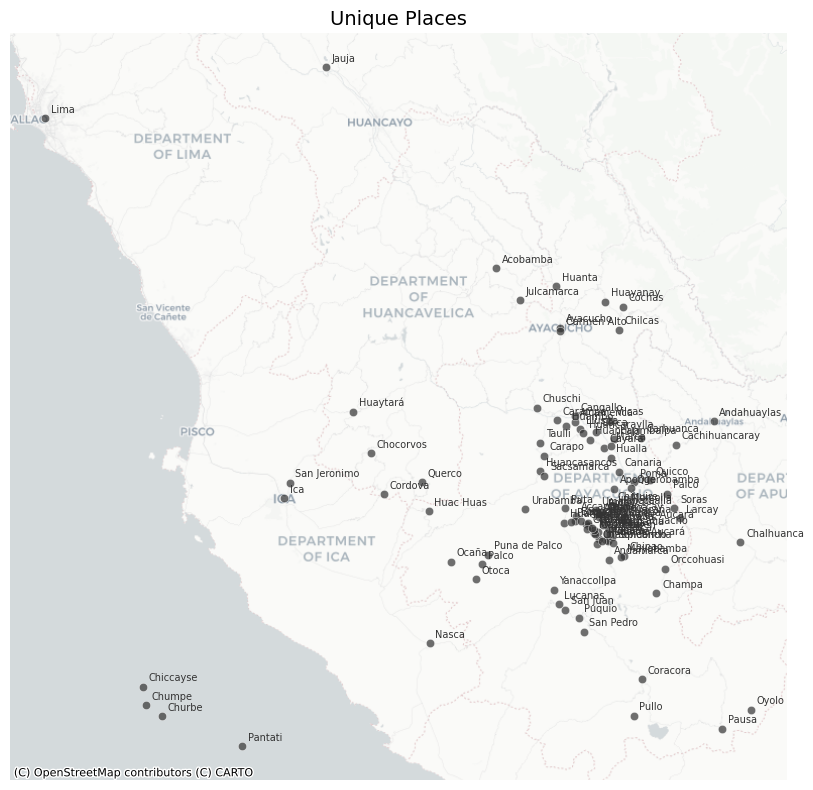

In [12]:
plot_places_on_map(result_df, place_column='standardize_label', map_title='Unique Places')

Because coordinates originate from the collaborator's GIS file, large-scale misplacements are rare. If any point appears clearly wrong, add a correction entry below.

In [13]:
# Add corrections here if any point appears misplaced in the map above.
# Format: {'place_name': <standardize_label>, 'latitude': <lat>, 'longitude': <lon>}
places_to_fix = []

In [14]:
for place in places_to_fix:
    mask = result_df['standardize_label'] == place['place_name']
    for key, val in place.items():
        if key != 'place_name':
            result_df.loc[mask, key] = val

result_df.to_csv('../data/clean/places.csv', index=True)
print(f"Saved {len(result_df)} places to data/clean/places.csv")

Saved 107 places to data/clean/places.csv


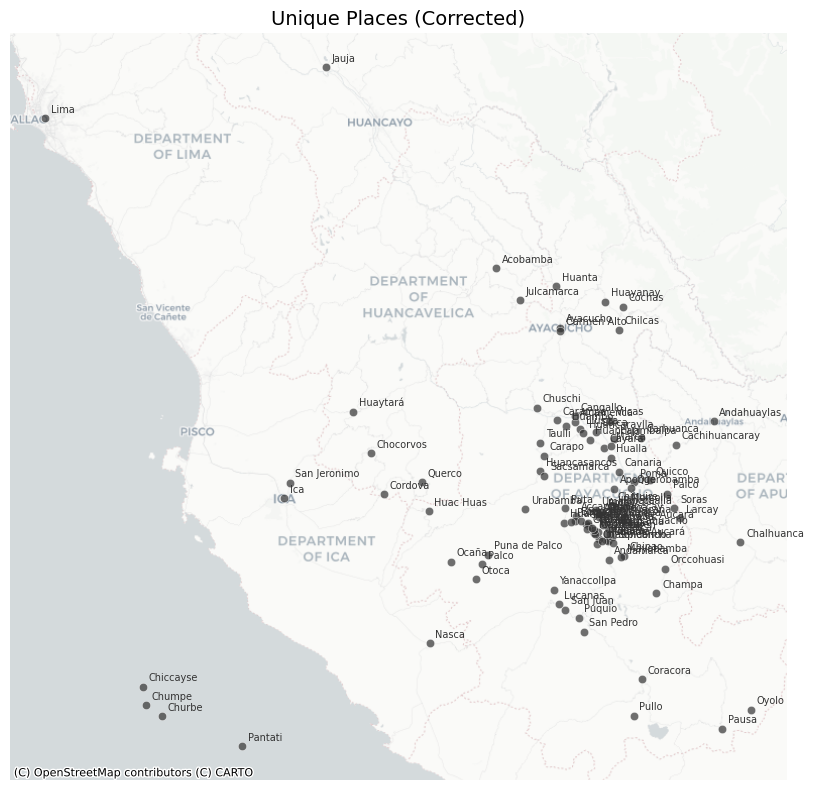

In [15]:
# visually check the corrected places on the map
plot_places_on_map(result_df, place_column='standardize_label', map_title='Unique Places (Corrected)')